# QGP PINN — Results Notebook

Loads the trained checkpoint, sweeps T at fixed muB/T ratios, and renders
each plot **on its own cell/output** (one graph per "page") instead of one
cluttered combined figure.

Physics/data logic is identical to `train_final.py` / the original
`plot_results_final.py` — only the figure layout changed.

## 1. Imports & Configuration

In [1]:
import sys
import warnings
from pathlib import Path
from typing import NamedTuple

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Works whether this notebook lives next to qgp_pinn.py/train_final.py,
# or one folder below (e.g. repo/plots/this_notebook.ipynb).
try:
    current_dir = Path(__file__).resolve().parent
except NameError:
    current_dir = Path.cwd()

for candidate in (current_dir, current_dir.parent):
    if (candidate / "qgp_pinn.py").exists():
        sys.path.insert(0, str(candidate))
        break

from qgp_pinn import build_qpm_pinn
from model.train_final import qpm_masses_from_g2, compute_thermo

In [2]:
CHECKPOINT_PATH = "./model/pinn_final_central.pth"
T_MIN = 0.155
T_MAX = 0.245
N_POINTS = 150
RATIOS_TO_PLOT = [0.0, 1.0, 2.0, 3.0]
T_C = 0.155
DPI = 300
OUTPUT_DIR = Path("./results")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

_C_RATIO = {0.0: "#000000", 1.0: "#d62728", 2.0: "#2ca02c", 3.0: "#1f77b4"}
_C_MASS  = {"m_g": "#2ca02c", "m_ud": "#ff7f0e", "m_s": "#9467bd"}

## 2. Model Loading & T-Sweep\n\nUnchanged from `plot_results_final.py` — same checkpoint loading, same physics.

In [3]:
class SweepResult(NamedTuple):
    T_np: np.ndarray; P_val: np.ndarray; s_val: np.ndarray; eps_val: np.ndarray
    delta_val: np.ndarray; nB_val: np.ndarray; g2: np.ndarray
    m_g: np.ndarray; m_ud: np.ndarray; m_s: np.ndarray


def load_model(path, device="cpu"):
    if not Path(path).exists():
        raise FileNotFoundError(f"Checkpoint not found: '{path}'")
    try:
        ckpt = torch.load(path, map_location=device, weights_only=True)
    except Exception:
        ckpt = torch.load(path, map_location=device)
    arch = ckpt.get("arch", {"hidden_width": 64, "num_blocks": 4, "dropout": 0.0})
    model = build_qpm_pinn(**arch)
    model.load_state_dict(ckpt["model_state_dict"])
    model.eval().to(device)
    return model


def run_sweep(pinn, T_min, T_max, n_pts, muB_over_T, device):
    T_lin = torch.linspace(T_min, T_max, n_pts, device=device).unsqueeze(1)
    mu_B_lin = T_lin * muB_over_T

    T_grad = T_lin.clone().requires_grad_(True)
    mu_B_grad = mu_B_lin.clone().requires_grad_(True)
    x = torch.cat([T_grad, mu_B_grad], dim=1)

    g2_g, _, _, _ = pinn(x)
    Mud, Ms, Mgluon = qpm_masses_from_g2(g2_g, T_grad, mu_B_grad)
    P_t, s_t, eps_t, nB_t, delta_t = compute_thermo(T_grad, mu_B_grad, Mud, Ms, Mgluon, device)

    return SweepResult(
        T_np=T_lin.squeeze().detach().cpu().numpy(),
        P_val=P_t.squeeze().detach().cpu().numpy(),
        s_val=s_t.squeeze().detach().cpu().numpy(),
        eps_val=eps_t.squeeze().detach().cpu().numpy(),
        delta_val=delta_t.squeeze().detach().cpu().numpy(),
        nB_val=nB_t.squeeze().detach().cpu().numpy(),
        g2=g2_g.squeeze().detach().cpu().numpy(),
        m_g=Mgluon.squeeze().detach().cpu().numpy(),
        m_ud=Mud.squeeze().detach().cpu().numpy(),
        m_s=Ms.squeeze().detach().cpu().numpy(),
    )

In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

model = load_model(CHECKPOINT_PATH, device=device)

sweeps = {}
for ratio in RATIOS_TO_PLOT:
    sweeps[ratio] = run_sweep(model, T_MIN, T_MAX, N_POINTS, ratio, device)

print("Sweep complete for muB/T ratios:", RATIOS_TO_PLOT)

Device: cuda
QPMPinn created — trainable parameters: 34,689
Sweep complete for muB/T ratios: [0.0, 1.0, 2.0, 3.0]


## 3. Styling Helpers & Overlay Data

In [5]:
def apply_style():
    try:
        plt.style.use("seaborn-v0_8-whitegrid")
    except OSError:
        plt.style.use("seaborn-whitegrid")
    plt.rcParams.update({
        "axes.facecolor": "white", "axes.edgecolor": "#cccccc", "axes.grid": True,
        "grid.color": "#e0e0e0", "grid.linestyle": "--", "grid.linewidth": 0.6,
        "axes.spines.top": False, "axes.spines.right": False,
    })


def label_ax(ax, xlabel, ylabel, title):
    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(title, fontsize=14, fontweight="bold", pad=10)
    ax.tick_params(labelsize=10)
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(2))
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator(2))


try:
    df_lat_full = pd.read_csv("./Data/Thermo_data_central.csv")
    df_lat_full = df_lat_full[(df_lat_full["T"] >= T_MIN) & (df_lat_full["T"] <= T_MAX)]
except FileNotFoundError:
    df_lat_full = None
    warnings.warn("Thermo_data_central.csv not found -- lattice overlay will be skipped.")

try:
    df_plumari = pd.read_csv("./Data/g2plumari.csv")
    df_plumari.columns = [c.strip() for c in df_plumari.columns]
except FileNotFoundError:
    df_plumari = None
    print("WARNING: g2plumari.csv not found -- Wuppertal-Budapest overlay will NOT appear.")

try:
    df_budapest = pd.read_csv("./Data/hotqcd.csv")
    df_budapest.columns = [c.strip() for c in df_budapest.columns]
except FileNotFoundError:
    df_budapest = None
    print("WARNING: hotqcd.csv not found -- HotQCD overlay will NOT appear.")

## 4. Equation of State — Pressure\n\nEach plot below renders in its own cell output (its own \"page\") and also saves to `results/`.

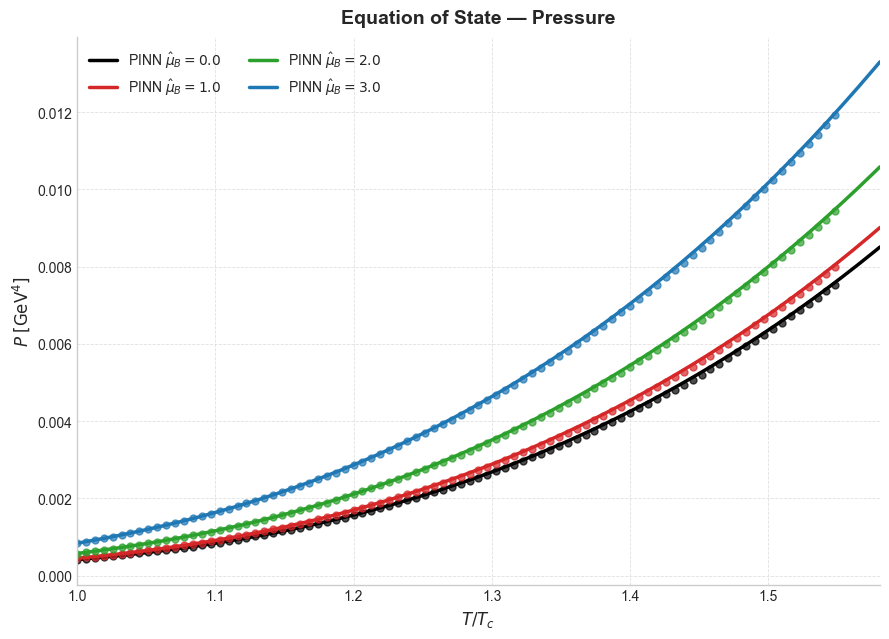

In [6]:
def plot_eos_observable(attr, ylabel, title, marker, lat_col, lat_power, filename):
    apply_style()
    fig, ax = plt.subplots(figsize=(9, 6.5))

    for ratio in RATIOS_TO_PLOT:
        res = sweeps[ratio]
        T = res.T_np / T_C
        color = _C_RATIO[ratio]
        ax.plot(T, getattr(res, attr), color=color, linewidth=2.5,
                 label=rf"PINN $\hat{{\mu}}_B={ratio}$")

        if df_lat_full is not None and lat_col in df_lat_full.columns:
            df_slice = df_lat_full[np.isclose(df_lat_full["MuB/T"], ratio, atol=1e-3)]
            if not df_slice.empty:
                T_lat_raw = df_slice["T"].values
                T_lat = T_lat_raw / T_C
                lat_val = df_slice[lat_col].values * (T_lat_raw ** lat_power)
                ax.plot(T_lat, lat_val, marker=marker, markersize=5, color=color,
                         linestyle="none", alpha=0.7)

    ax.set_xlim(1.0, sweeps[RATIOS_TO_PLOT[-1]].T_np.max() / T_C)
    label_ax(ax, r"$T/T_c$", ylabel, title)
    ax.legend(fontsize=10, loc="upper left", ncol=2)
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / filename, dpi=DPI, bbox_inches="tight", facecolor="white")
    plt.show()


plot_eos_observable("P_val", r"$P\;[\mathrm{GeV}^4]$", "Equation of State — Pressure",
                     "o", "P/T^4", 4, "eos_P.png")

## 5. Equation of State — Entropy Density

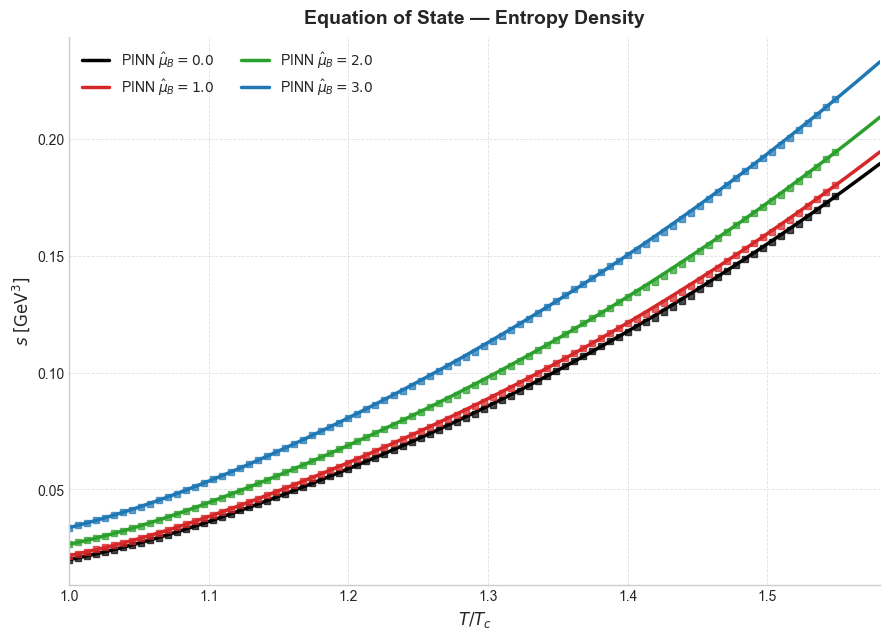

In [7]:
plot_eos_observable("s_val", r"$s\;[\mathrm{GeV}^3]$", "Equation of State — Entropy Density",
                     "s", "s/T^3", 3, "eos_s.png")

## 6. Equation of State — Energy Density

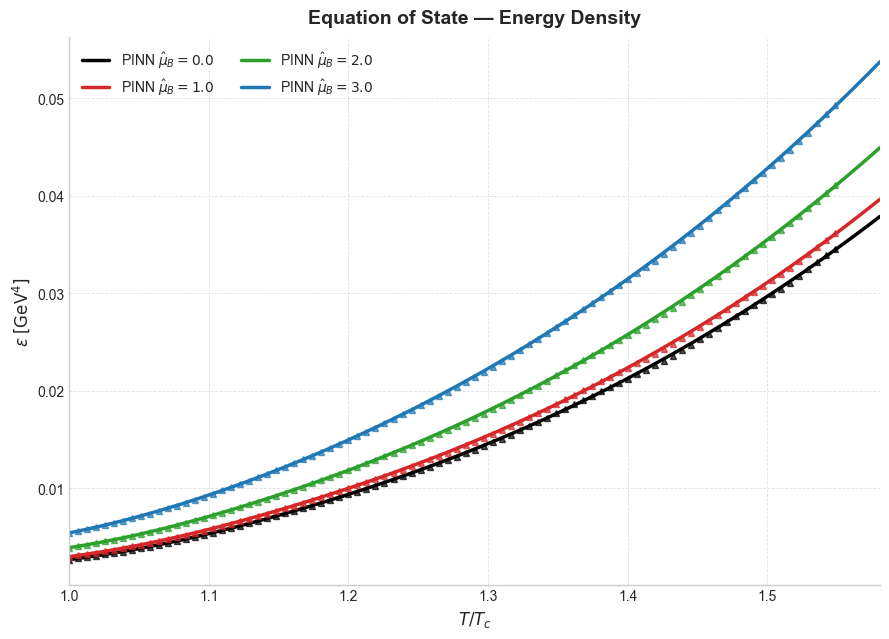

In [8]:
plot_eos_observable("eps_val", r"$\epsilon\;[\mathrm{GeV}^4]$", "Equation of State — Energy Density",
                     "^", "E/T^4", 4, "eos_eps.png")

## 7. Equation of State — Trace Anomaly

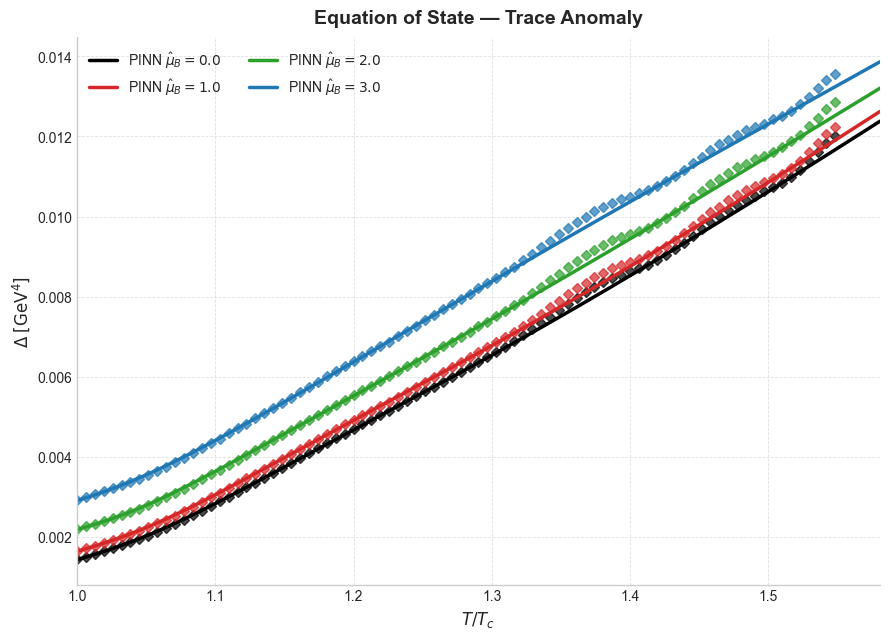

In [9]:
plot_eos_observable("delta_val", r"$\Delta\;[\mathrm{GeV}^4]$", "Equation of State — Trace Anomaly",
                     "D", "TraceA", 4, "eos_delta.png")

## 8. Equation of State — Net Baryon Density

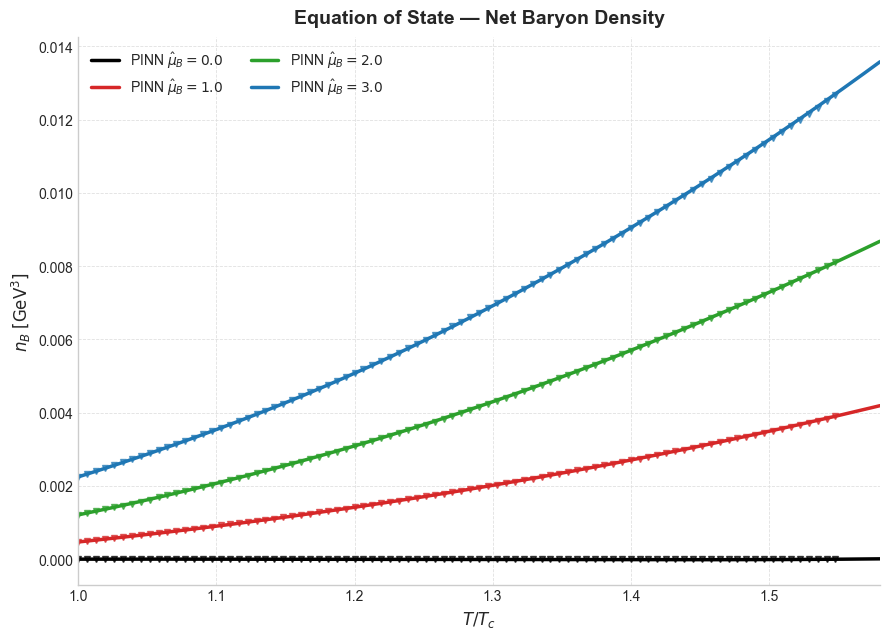

In [10]:
plot_eos_observable("nB_val", r"$n_B\;[\mathrm{GeV}^3]$", "Equation of State — Net Baryon Density",
                     "v", "nB/T^3", 3, "eos_nB.png")

## 9. Effective Coupling Constant $g^2(T, \\mu_B)$

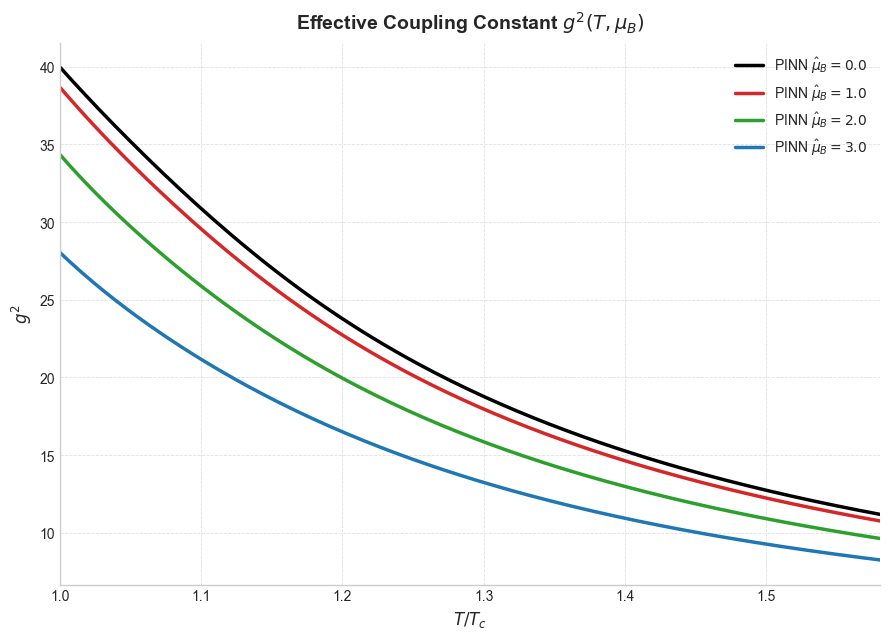

In [11]:
apply_style()
fig, ax = plt.subplots(figsize=(9, 6.5))

for ratio in RATIOS_TO_PLOT:
    res = sweeps[ratio]
    T = res.T_np / T_C
    ax.plot(T, res.g2, color=_C_RATIO[ratio], linewidth=2.5,
             label=rf"PINN $\hat{{\mu}}_B={ratio}$")

ax.set_xlim(1.0, sweeps[RATIOS_TO_PLOT[-1]].T_np.max() / T_C)
label_ax(ax, r"$T/T_c$", r"$g^2$", r"Effective Coupling Constant $g^2(T, \mu_B)$")
ax.legend(fontsize=10, loc="upper right")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "coupling_g2.png", dpi=DPI, bbox_inches="tight", facecolor="white")
plt.show()

## 10. Effective Coupling Constant $g(T, \\mu_B)$ — with literature overlays

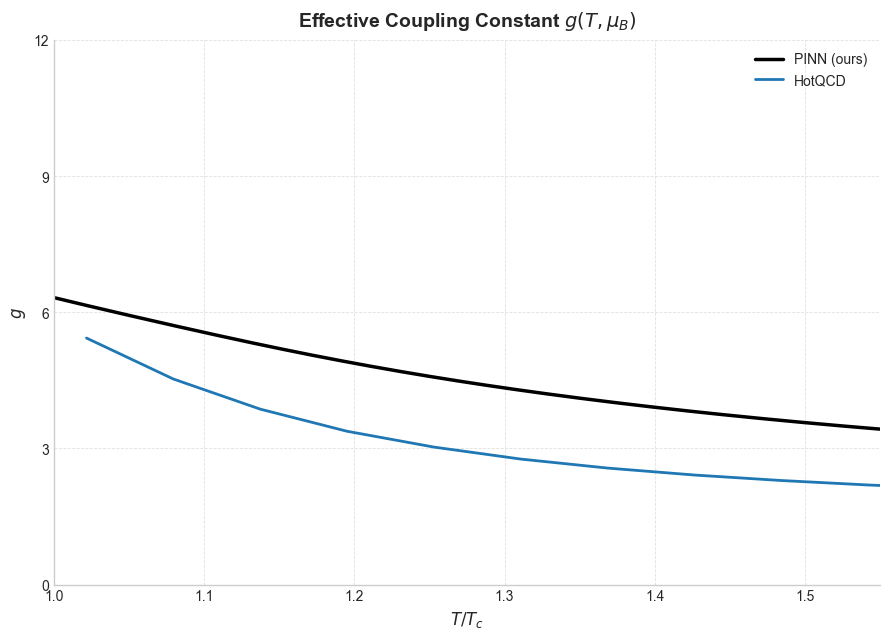

In [12]:
apply_style()
fig, ax = plt.subplots(figsize=(9, 6.5))

res0 = sweeps[0.0]
T = res0.T_np / T_C
ax.plot(T, np.sqrt(res0.g2), color="black", linewidth=2.5, label="PINN (ours)")

if df_plumari is not None:
    df_p = df_plumari.sort_values("x")
    df_p = df_p[df_p["x"] >= 1.0]
    ax.plot(df_p["x"], df_p["y"], color="red", linewidth=2.0, label="Wuppertal-Budapest")

if df_budapest is not None:
    df_b = df_budapest.sort_values("x")
    df_b = df_b[df_b["x"] >= 1.0]
    ax.plot(df_b["x"], df_b["y"], color="#1f77b4", linewidth=2.0, label="HotQCD")

ax.set_xlim(1.0, 1.55)
ax.set_yticks([0, 3, 6, 9, 12])
label_ax(ax, r"$T/T_c$", r"$g$", r"Effective Coupling Constant $g(T, \mu_B)$")
ax.legend(fontsize=10, loc="upper right")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "coupling_g.png", dpi=DPI, bbox_inches="tight", facecolor="white")
plt.show()

## 11. QPM Quasi-Particle Thermal Masses

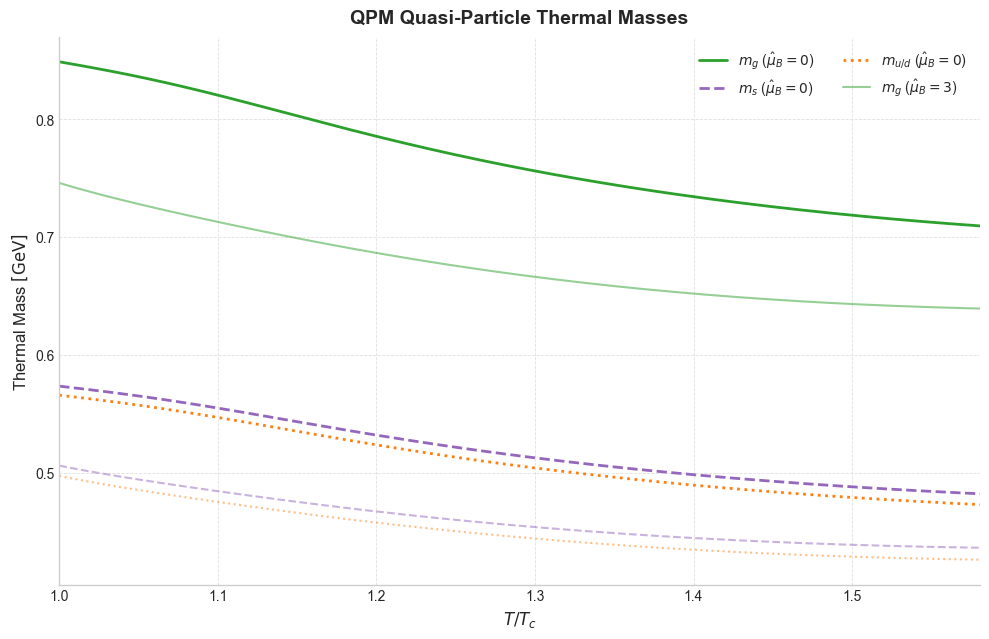

In [13]:
apply_style()
fig, ax = plt.subplots(figsize=(10, 6.5))

res0 = sweeps[0.0]
T0 = res0.T_np / T_C
ax.plot(T0, res0.m_g,  color=_C_MASS["m_g"],  linewidth=2.0, label=r"$m_g$ ($\hat{\mu}_B=0$)")
ax.plot(T0, res0.m_s,  color=_C_MASS["m_s"],  linewidth=2.0, linestyle="--", label=r"$m_s$ ($\hat{\mu}_B=0$)")
ax.plot(T0, res0.m_ud, color=_C_MASS["m_ud"], linewidth=2.0, linestyle=":", label=r"$m_{u/d}$ ($\hat{\mu}_B=0$)")

res3 = sweeps[3.0]
T3 = res3.T_np / T_C
ax.plot(T3, res3.m_g,  color=_C_MASS["m_g"],  linewidth=1.5, alpha=0.5, label=r"$m_g$ ($\hat{\mu}_B=3$)")
ax.plot(T3, res3.m_s,  color=_C_MASS["m_s"],  linewidth=1.5, linestyle="--", alpha=0.5)
ax.plot(T3, res3.m_ud, color=_C_MASS["m_ud"], linewidth=1.5, linestyle=":", alpha=0.5)

ax.set_xlim(1.0, T0.max())
label_ax(ax, r"$T/T_c$", r"Thermal Mass $\mathrm{[GeV]}$", r"QPM Quasi-Particle Thermal Masses")
ax.legend(fontsize=10, loc="upper right", ncol=2)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "thermal_masses.png", dpi=DPI, bbox_inches="tight", facecolor="white")
plt.show()

## 12. Export Predictions to CSV

In [14]:
all_data = []
for ratio, res in sweeps.items():
    df = pd.DataFrame({
        "muB/T": ratio, "T [GeV]": res.T_np, "T/T_c": res.T_np / T_C,
        "P [GeV^4]": res.P_val, "s [GeV^3]": res.s_val, "eps [GeV^4]": res.eps_val,
        "Delta [GeV^4]": res.delta_val, "nB [GeV^3]": res.nB_val,
        "g^2": res.g2, "g": np.sqrt(res.g2),
        "m_g [GeV]": res.m_g, "m_{u/d} [GeV]": res.m_ud, "m_s [GeV]": res.m_s,
    })
    all_data.append(df)

out_csv = OUTPUT_DIR / "PINN_Final_Predictions_GeV.csv"
pd.concat(all_data, ignore_index=True).to_csv(out_csv, index=False)
print(f"Data exported -> {out_csv}")

Data exported -> results\PINN_Final_Predictions_GeV.csv


In [15]:
##13. Total Loss v/s Epochs

Loaded 5000 epochs of loss history.


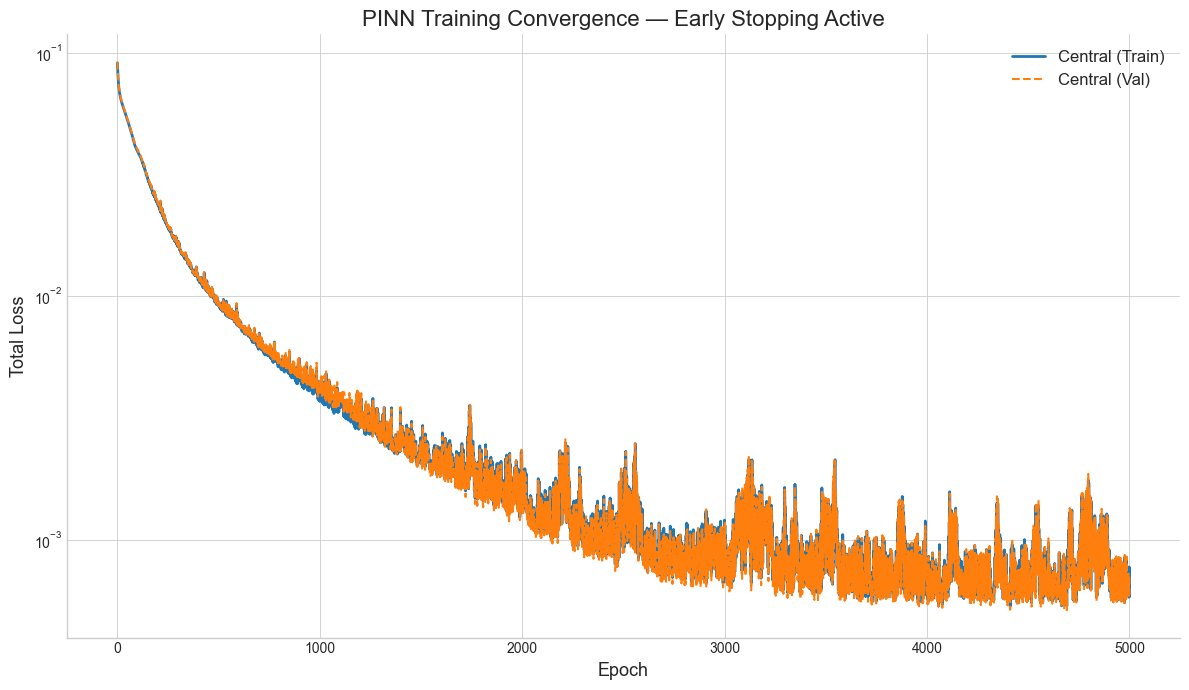

In [16]:

LOSS_TRAIN_PATH = "./model/Loss_all.npy"
LOSS_VAL_PATH   = "./model/Loss_validation.npy"


def plot_loss_curve(train_hist, val_hist):
    plt.style.use("seaborn-v0_8-whitegrid")
    fig, ax = plt.subplots(figsize=(12, 7))

    epochs = range(1, len(train_hist) + 1)
    ax.plot(epochs, train_hist, label="Central (Train)", color="#1f77b4", linewidth=2.0)
    ax.plot(epochs, val_hist,   label="Central (Val)",   color="#ff7f0e", linewidth=1.5, linestyle="--")

    ax.set_yscale("log")
    ax.set_xlabel("Epoch", fontsize=13)
    ax.set_ylabel("Total Loss", fontsize=13)
    ax.set_title("PINN Training Convergence — Early Stopping Active", fontsize=16)
    ax.legend(fontsize=12)

    plt.tight_layout()
    plt.show()  # This will display the plot in your notebook


if __name__ == "__main__":
    train_hist = np.load(LOSS_TRAIN_PATH)
    val_hist = np.load(LOSS_VAL_PATH)
    print(f"Loaded {len(train_hist)} epochs of loss history.")
    plot_loss_curve(train_hist, val_hist)